In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import os
os.environ["OMP_NUM_THREADS"] = "5"  # Limit OpenMP
os.environ["MKL_NUM_THREADS"] = "5"  # Limit MKL (Intel Math Kernel Library)
os.environ["OPENBLAS_NUM_THREADS"] = "5"  # Limit OpenBLAS
os.environ["NUMEXPR_MAX_THREADS"] = "5"  # Limit NumExpr if installed

In [10]:
import itertools
from pathlib import Path
import re
from typing import Literal

from matplotlib.colors import CenteredNorm
from matplotlib import transforms
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import pickle
from scipy import stats
from scipy.stats import ttest_ind, pearsonr, spearmanr
import seaborn as sns
import textgrid
import torch
from tqdm.auto import tqdm
tqdm.pandas()

from src.data import get_electrode_df, add_metadata_features
from src.models.causal4 import run_causal4_analysis
from src.models import causal4
import src.viz as viz

In [55]:
epochs_path = "outputs/epochs_preprocessed"
tg_dir = "textgrids"

include_rois = ["superiortemporal", "postcentral", "precentral", "supramarginal", "inferiortemporal", "middletemporal",
                "parsopercularis", "caudalmiddlefrontol", "lateralorbitofrontal", "temporalpole", "inferiorparietal",
                "rostralmiddlefrontal", "parstriangularis"]

# uncorrected p-value threshold
alpha = 0.01

# ERP sources from TIMIT data
timit_epoch_sources = {
    "All": "/userdata/jgauthier/projects/ideal-word-representations/phoneme_epochs-all.h5",
    "Word onset": "/userdata/jgauthier/projects/ideal-word-representations/phoneme_epochs-onsets.h5",
}

outdir = "outputs/causal4_searchlight"

In [12]:
all_epoch_paths = list(Path(epochs_path).glob("*.fif"))

In [13]:
epochs = {}
for path in tqdm(all_epoch_paths):
    subject_name = re.findall("(EC[\d]+)_epo", str(path))[0]
    epochs[subject_name] = mne.read_epochs(str(path))
    epochs[subject_name].metadata = add_metadata_features(epochs[subject_name].metadata)

  0%|          | 0/10 [00:00<?, ?it/s]

Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC278_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matrices available
Adding metadata with 72 columns
1152 matching events found
No baseline correction applied
0 projection items activated
Replacing existing metadata with 100 columns
Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC270_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matrices available
Adding metadata with 72 columns
432 matching events found
No baseline correction applied
0 projection items activated
Replacing existing metadata with 100 columns
Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC253_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matri

In [14]:
electrode_df = pd.concat([get_electrode_df(subject_name) for subject_name in epochs.keys()],
                         keys=epochs.keys(), names=["subject"])
electrode_df["roi"] = electrode_df.roi.astype(str)
electrode_df = electrode_df.droplevel("electrode_name")

# Drop electrodes metadata which don't have corresponding data
for subject, epochs_i in epochs.items():
    electrode_df.loc[subject, "keep"] = np.arange(len(electrode_df.loc[subject])) < len(epochs_i.info["ch_names"])
electrode_df = electrode_df[electrode_df["keep"]].drop(columns="keep")

electrode_df

long_name   type                         roi
subject electrode_idx                                                  
EC278   0                  Temporal1   grid              middletemporal
        1                  Temporal2   grid              middletemporal
        2                  Temporal3   grid              middletemporal
        3                  Temporal4   grid              middletemporal
        4                  Temporal5   grid              middletemporal
...                              ...    ...                         ...
EC282   217             Hippocampus6  depth  ctx_lh_S_collat_transv_ant
        218             Hippocampus7  depth  ctx_lh_S_collat_transv_ant
        219             Hippocampus8  depth  Left-Cerebral-White-Matter
        220             Hippocampus9  depth       ctx_lh_G_temporal_inf
        221            Hippocampus10  depth  Left-Cerebral-White-Matter

[2332 rows x 3 columns]

## Find speech-responsive electrodes

In [15]:
# power threshold relative to pre-speech baseline which defines a "speech responsive" electrode
# if we see absolute value change >= this threshold, call the electrode speech-responsive
speech_responsive_threshold = 0.3

Applying baseline correction (mode: mean)


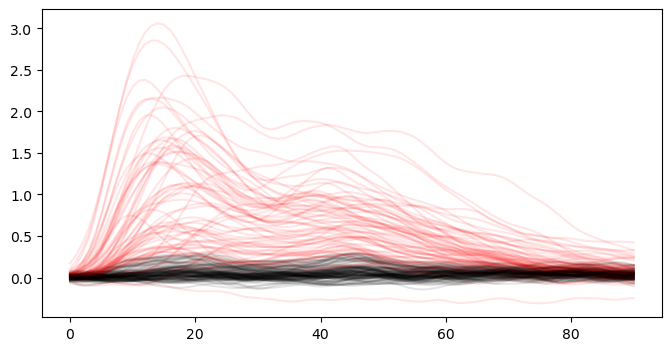

In [16]:
# demo this
dd = next(iter(epochs.values())).copy().apply_baseline((-0.1, 0)).average().crop(tmin=0, tmax=0.9).get_data()
keep = np.abs(dd).max(axis=1) > speech_responsive_threshold

f, ax = plt.subplots(figsize=(8, 4))
for line, k in zip(dd, keep):
    plt.plot(line, color="r" if k else "k", alpha=0.1)

In [17]:
for subject, epochs_i in epochs.items():
    epochs_i = epochs_i.copy().apply_baseline((-0.1, 0)).average().crop(tmin=0, tmax=0.9).get_data()
    assert epochs_i.ndim == 2
    speech_responsive_i = np.abs(epochs_i).max(axis=1) > speech_responsive_threshold

    if len(speech_responsive_i) > len(electrode_df.loc[subject]):
        speech_responsive_i = speech_responsive_i[:len(electrode_df.loc[subject])]
    electrode_df.loc[subject, "speech_responsive"] = speech_responsive_i

Applying baseline correction (mode: mean)


Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


In [18]:
electrode_df = electrode_df.astype({"speech_responsive": bool})

## Model sketch

In [19]:
import json
with open("causal_candidate_populations.json", "r") as f:
    populations = json.load(f)

In [20]:
populations

[{'phoneme_pair': 'dn',
  'subject': 'EC282',
  'cluster_a': 5,
  'cluster_b': 2,
  'electrodes_a': [98, 99, 106],
  'electrodes_b': [82,
   103,
   104,
   105,
   107,
   113,
   114,
   115,
   122,
   124,
   140,
   155,
   164,
   197],
  'window_a': [0.1, 0.5],
  'window_b': [1.0, 1.4]},
 {'phoneme_pair': 'dn',
  'subject': 'EC253',
  'cluster_a': 0,
  'cluster_b': 3,
  'electrodes_a': [3, 20, 22, 36, 37, 53, 196, 197],
  'electrodes_b': [2, 23, 24, 51, 179, 180, 195, 243],
  'window_a': [0.1, 0.55],
  'window_b': [1.15, 1.8]},
 {'phoneme_pair': 'dn',
  'subject': 'EC282',
  'cluster_a': 0,
  'cluster_b': 2,
  'electrodes_a': [117],
  'electrodes_b': [82,
   103,
   104,
   105,
   107,
   113,
   114,
   115,
   122,
   124,
   140,
   155,
   164,
   197],
  'window_a': [0.1, 0.55],
  'window_b': [1.0, 1.4]},
 {'phoneme_pair': 'dn',
  'subject': 'EC270',
  'cluster_a': 5,
  'cluster_b': 2,
  'electrodes_a': [74, 118, 124],
  'electrodes_b': [64, 80, 108, 119, 120, 123],
  'win

In [21]:
from tqdm.auto import trange

all_results = []
all_results_meta = {}
populations_dict = {}

# NB, with split_strategy="extreme", what's being randomized across runs
# is only the shuffling in the nested CV splits for estimating phase 1/2
# encoders.
n_repeats = 10
split_strategy = "extreme" # "stratify" or "extreme"

for repeat in trange(n_repeats):
    for population in tqdm(populations, leave=False):
        result = run_causal4_analysis(
            epochs, subject=population["subject"],
            phoneme_pair=population["phoneme_pair"],
            population_A=population["electrodes_a"],
            population_A_window=population["window_a"],
            split_strategy=split_strategy,
        )

        key = (population["subject"], population["phoneme_pair"],
               str(population["cluster_a"]))
        populations_dict[key] = population

        repeat_key = (key, repeat)
        all_results_meta[repeat_key] = result

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

/scratch/jgauthier/transformers3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1458: RuntimeWarning: divide by zero encountered in log
  return np.log(self.predict_proba(X))


  0%|          | 0/26 [00:00<?, ?it/s]

...

  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

In [22]:
decoder_results = pd.DataFrame([
    {
        "name": "_".join(key[0]),
        "repeat": key[1],
        "subject": result.subject,
        "population_A": result.population_A,
        "population_A_window": result.population_A_window,

        "roc_auc_val": result.phase1_val_score,
    }
    for key, result in all_results_meta.items()
])

In [23]:
decoder_results.groupby("name").roc_auc_val.agg(["mean", "std"]).sort_values("mean")

,mean,std
name,,
EC282_pb_3,0.426259,0.027092
EC270_dn_5,0.479905,0.045143
EC270_dn_0,0.483941,0.030159
EC287_dn_5,0.589111,0.031080
EC270_pb_3,0.593403,0.082941
EC253_dn_5,0.598155,0.030576
EC282_bm_3,0.635069,0.047077
EC250_bm_6,0.648199,0.027910
EC243_bm_6,0.678624,0.023371


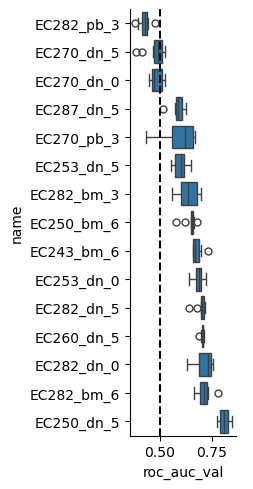

In [24]:
order = decoder_results.groupby("name").roc_auc_val.agg(["mean", "std"]).sort_values("mean").index
g = sns.catplot(data=decoder_results.reset_index(), x="roc_auc_val", y="name", order=order, kind="box", aspect=0.5, height=5)
g.axes.flat[0].axvline(0.5, color="k", linestyle="--")
None

In [25]:
# study relationship between left phoneme probability and resampled value for each population A
calibration_df = []
for ((subject, phoneme_pair, population_A), repeat), result in all_results_meta.items():
    calibration_df.append(
        pd.concat([pd.Series(result.p_left_phoneme, name="p_left_phoneme"),
                   result.test_trial_metadata.reset_index()[["index", "resampled", "behavior_categorical", "label_behavior"]]], axis=1).assign(
                   subject=subject, phoneme_pair=phoneme_pair, population_A=population_A, repeat=repeat
                   ))
calibration_df = pd.concat(calibration_df)
calibration_df["site"] = calibration_df.subject + " " + calibration_df.phoneme_pair + " " + calibration_df.population_A

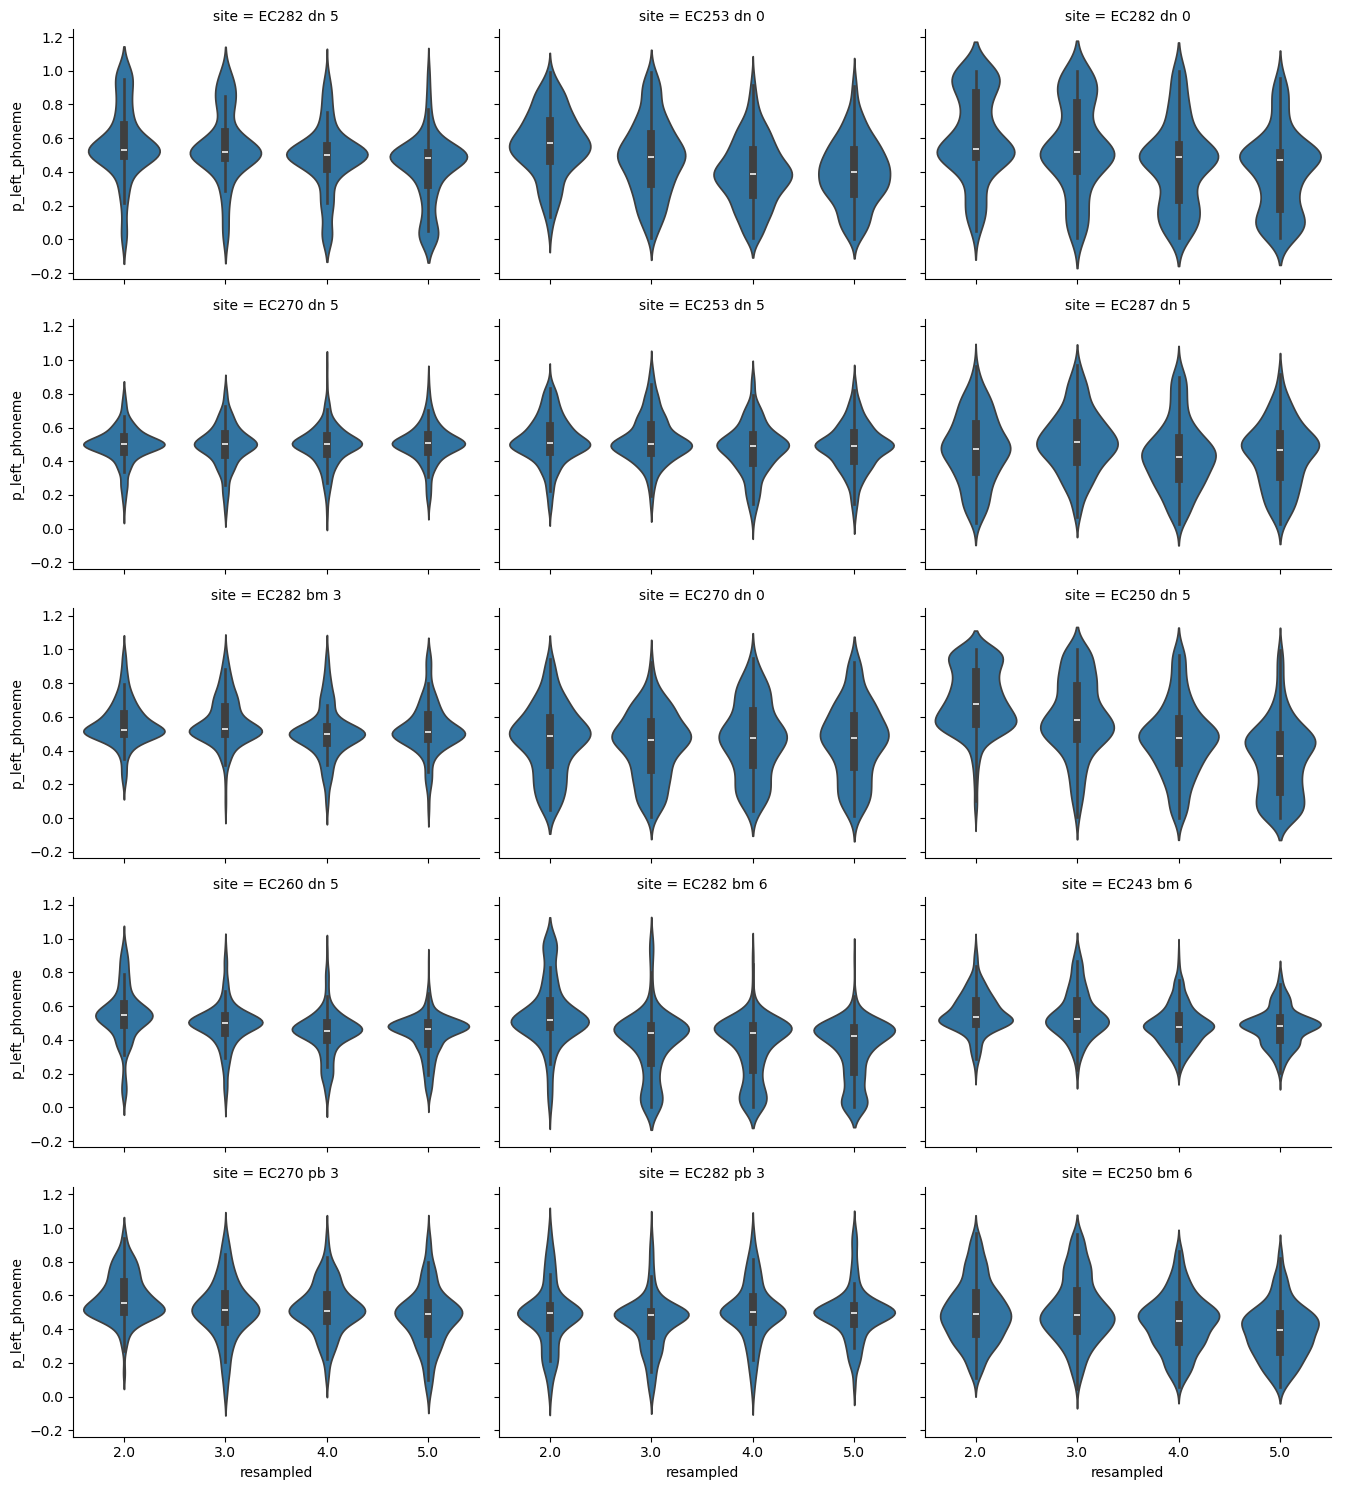

In [26]:
sns.catplot(data=calibration_df, x="resampled", y="p_left_phoneme",
            col="site", col_wrap=3, kind="violin", height=3, aspect=1.5)

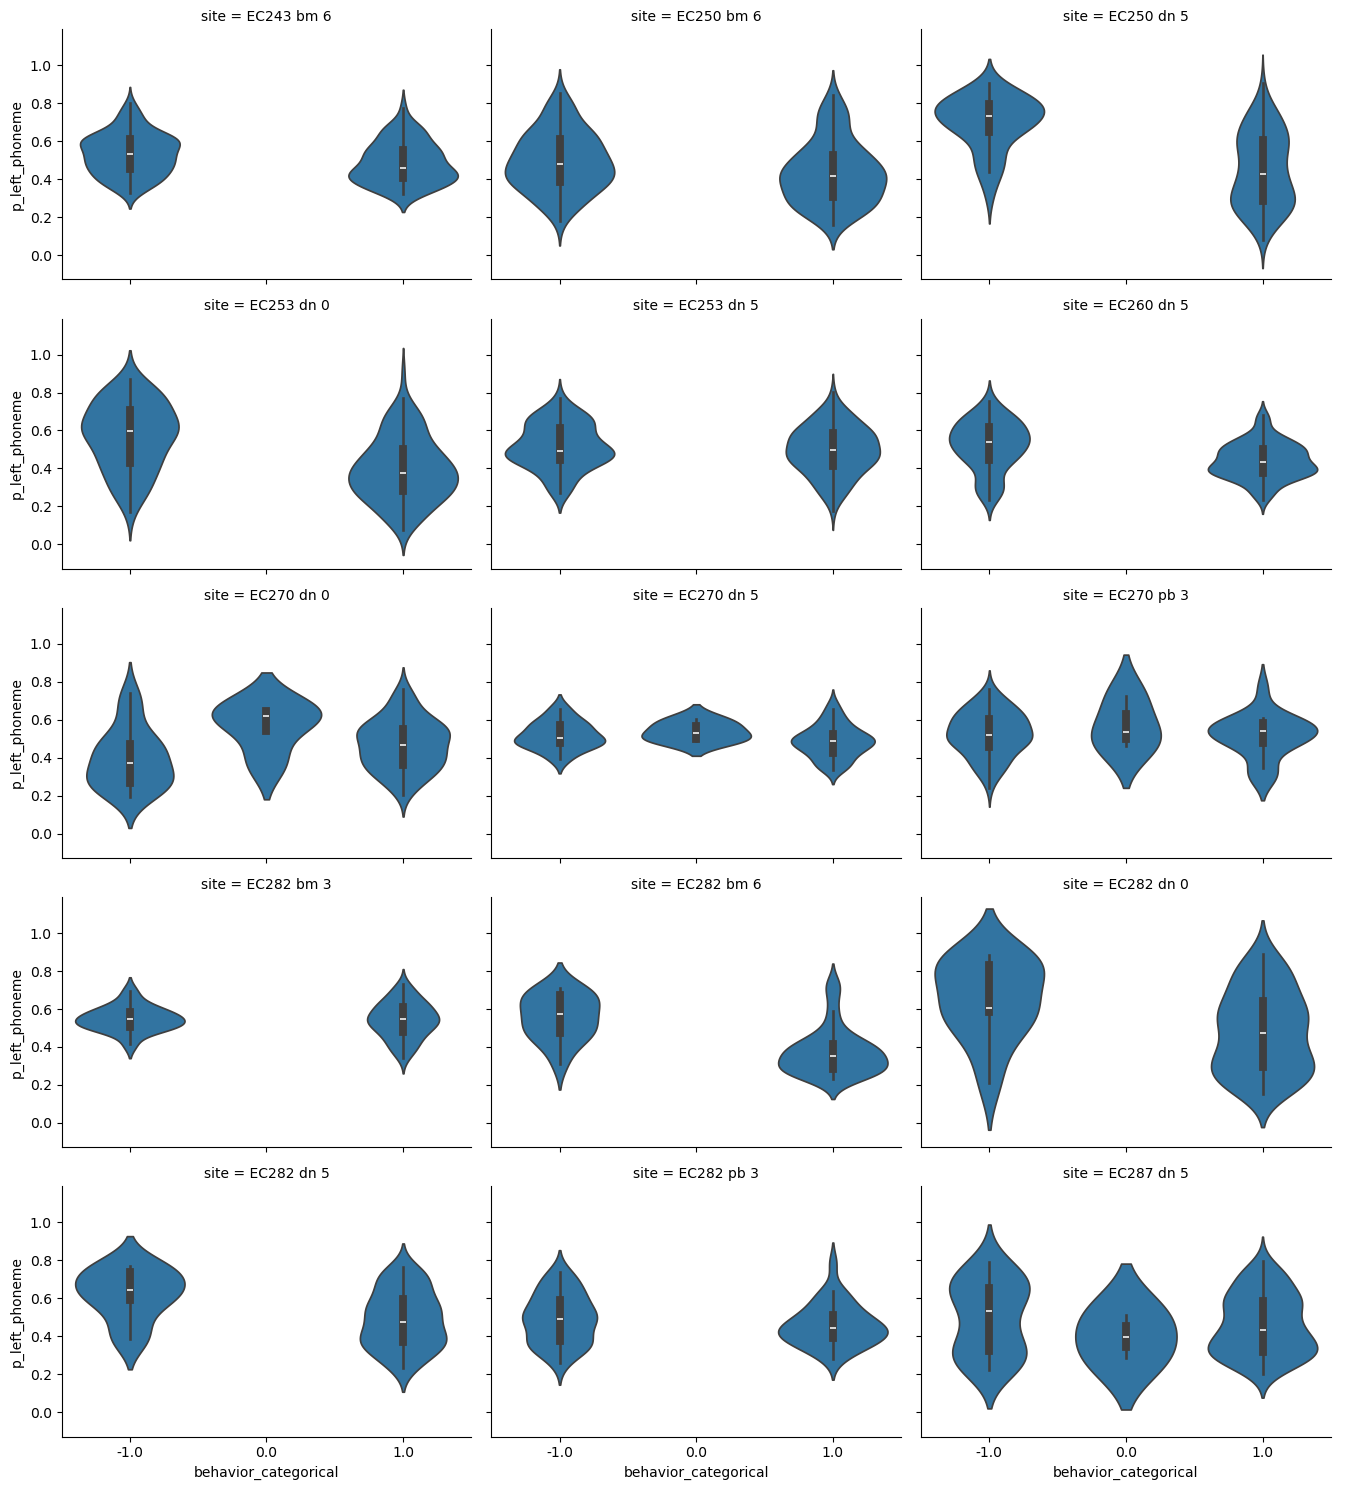

In [27]:
sns.catplot(data=calibration_df.groupby(["site", "subject", "phoneme_pair", "population_A", "resampled", "index"])[["behavior_categorical", "p_left_phoneme"]].mean().reset_index(),
            x="behavior_categorical", y="p_left_phoneme",
            col="site", col_wrap=3, kind="violin", height=3, aspect=1.5)

In [28]:
calibration_df.to_csv("calibration_df.csv", index=False)

## Start B searchlight

In [29]:
# prepare_searchlight_windows({"align_to": "onset", "window_start": 0, "window_end": 0.1, "window_size": 0.05},
#                             epochs=eval_epochs[mask])

In [30]:
# prepare_searchlight_windows({"align_to": "word_offset", "window_start": -0.1, "window_end": 0.1, "window_size": 0.05},
#                             epochs=eval_epochs[~mask], global_tmin=0.5)

In [31]:
searchlight_results = {}

searchlight_specs = {
    "onset": causal4.SearchlightSpec(
        align_to="onset",
        window_size=0.3,
        window_start=0.5,
        window_end=2.5,
    ),
    # "word_offset": {
    #     "align_to": "word_offset",
    #     "window_size": 0.1,
    #     "window_start": -0.3,
    #     "window_end": 0.3,
    # }
}

searchlight_method = "spearmanr"  # ttest, spearmanr, or pearsonr

# pre-compute p(gt phoneme) for all experiments
searchlight_decoder_outputs = {}
for experiment in populations_dict.keys():
    subject, phoneme_pair, population_A = experiment
    
    p_gt_phoneme = np.array([all_results_meta[(experiment, repeat)].p_gt_phoneme
                             for repeat in range(n_repeats)]).T
    p_gt_phoneme_mean = p_gt_phoneme.mean(1)

    test_trial_metadata = all_results_meta[(experiment, 0)].test_trial_metadata
    mask_left = test_trial_metadata.lexical_evidence == 0

    searchlight_decoder_outputs[experiment] = {
        "p_gt_phoneme_mean": p_gt_phoneme_mean,
        "test_trial_metadata": all_results_meta[(experiment, 0)].test_trial_metadata,
        "mask_left": mask_left,
    }

searchlight_electrode_activations = {}
for experiment in tqdm(populations_dict.keys()):
    subject, phoneme_pair, population_A = experiment
    result_key = (subject, phoneme_pair, population_A)
    prev_results = all_results_meta[experiment, 0]

    population_spec = populations_dict[experiment]
    population_A_start_window, population_A_end_window = population_spec["window_a"]

    # outcome from A population which will be correlated with HGA: p(gt phoneme)
    this_decoder_outputs = searchlight_decoder_outputs[experiment]
    test_trial_metadata = this_decoder_outputs["test_trial_metadata"]
    p_gt_phoneme_mean = this_decoder_outputs["p_gt_phoneme_mean"]
    # control quantity: `resampled` value for the trial
    control_predictor = test_trial_metadata.resampled

    eval_epochs = prev_results.epochs[test_trial_metadata.index]
    mask_left = this_decoder_outputs["mask_left"]

    for side, mask in [("left", mask_left), ("right", ~mask_left)]:
        eval_epochs_side = eval_epochs[mask]
        eval_epochs_side_data = eval_epochs_side.get_data()
        p_gt_phoneme_mean_side = p_gt_phoneme_mean[mask]
        control_predictor_side = control_predictor[mask]

        for spec_name, spec in searchlight_specs.items():
            windows = causal4.prepare_searchlight_windows(
                spec, eval_epochs_side,
                global_tmin=population_A_end_window if spec.align_to == "onset" else None,
                textgrid_dir=tg_dir)

            for window_start, window_end, relative_window_start, relative_window_end in windows:
                # get the data for this window
                window_data = eval_epochs_side_data[:, :, window_start:window_end]
                # average across time
                window_data_mean = window_data.mean(2)

                searchlight_electrode_activations[*experiment, window_start, window_end, side] = {
                    "metadata": test_trial_metadata,
                    "mask_left": mask_left,
                    "window_data_mean": window_data_mean,
                    "control_predictor": control_predictor_side,
                }

                if searchlight_method == "spearmanr":
                    side_test = [spearmanr(window_data_mean[:, i], p_gt_phoneme_mean_side)
                                    for i in range(window_data_mean.shape[1])]
                    corr, pval = zip(*side_test)

                    control_side_test = [spearmanr(window_data_mean[:, i], control_predictor_side)
                                            for i in range(window_data_mean.shape[1])]
                    control_corr, control_pval = zip(*control_side_test)
                elif searchlight_method == "pearsonr":
                    corr, pval = pearsonr(window_data_mean, p_gt_phoneme_mean_side[:, None], axis=0)
                    control_corr, control_pval = pearsonr(window_data_mean, control_predictor_side[:, None], axis=0)

                searchlight_results[*result_key, window_start, side] = pd.DataFrame({
                    "corr": corr,
                    "p_val": pval,
                    "control_corr": control_corr,
                    "control_p_val": control_pval,

                    "searchlight_spec": spec_name,
                    "side": side,
                    "population_A": population_A,
                    "phoneme_pair": phoneme_pair,
                    "subject": subject,

                    "electrode_idx": np.arange(len(corr)),
                    "electrode_in_A": np.isin(np.arange(len(corr)),
                                                population_spec["electrodes_a"]),

                    "window_start_samp": window_start,
                    "window_end_samp": window_end,
                    "window_start": prev_results.epochs.times[window_start],
                    "window_end": prev_results.epochs.times[window_end],

                    "relative_window_start_samp": relative_window_start,
                    "relative_window_end_samp": relative_window_end,
                    "relative_window_start": prev_results.epochs.times[relative_window_start],
                    "relative_window_end": prev_results.epochs.times[relative_window_end],
                })

  0%|          | 0/15 [00:00<?, ?it/s]

In [32]:
# Convert to a wide df with one row per spatiotemporal sample 
# (searchlight paradigm + electrode + phoneme pair + window)

def group_sides(site_rows):
    repr_row = site_rows.iloc[0].copy()
    copy_cols = ["searchlight_spec", "population_A", "phoneme_pair", "subject",
                 "electrode_idx", "electrode_in_A",
                 "relative_window_start_samp", "relative_window_end_samp",
                 "relative_window_start", "relative_window_end"]
    ret = {col: repr_row[col] for col in copy_cols}
    
    assert site_rows.side.nunique() == len(site_rows)
    for _, row in site_rows.iterrows():
        ret["window_start_" + row.side] = row.window_start
        ret["window_end_" + row.side] = row.window_end
        ret["window_start_samp_" + row.side] = row.window_start_samp
        ret["window_end_samp_" + row.side] = row.window_end_samp
        ret["corr_" + row.side] = row["corr"]
        ret["p_val_" + row.side] = row.p_val
        ret["control_corr_" + row.side] = row.control_corr
        ret["control_p_val_" + row.side] = row.control_p_val

    # Sometimes we miss a side, e.g. if the behavioral onset is different in the
    # two sides and we choose to crop one side shorter than the other.
    for side in ["left", "right"]:
        if f"window_start_{side}" not in ret:
            ret[f"window_start_{side}"] = np.nan
            ret[f"window_end_{side}"] = np.nan
            ret[f"window_start_samp_{side}"] = np.nan
            ret[f"window_end_samp_{side}"] = np.nan
            ret[f"corr_{side}"] = np.nan
            ret[f"p_val_{side}"] = np.nan
            ret[f"control_corr_{side}"] = np.nan
            ret[f"control_p_val_{side}"] = np.nan

    ret = pd.Series(ret)
    # sort the keys to have a consistent order
    ret = ret.sort_index()
    return ret

searchlight_results_df = pd.concat(searchlight_results.values()) \
    .groupby(["subject", "phoneme_pair", "population_A", "searchlight_spec",
              "relative_window_start_samp", "relative_window_end_samp",
              "electrode_idx", "electrode_in_A"], as_index=False) \
    .progress_apply(group_sides)
searchlight_results_df

  0%|          | 0/19392 [00:00<?, ?it/s]

,control_corr_left,control_corr_right,control_p_val_left,control_p_val_right,corr_left,corr_right,electrode_idx,electrode_in_A,p_val_left,p_val_right,...,searchlight_spec,subject,window_end_left,window_end_right,window_end_samp_left,window_end_samp_right,window_start_left,window_start_right,window_start_samp_left,window_start_samp_right
0,0.095485,-0.062536,0.354748,0.544986,-0.059183,-0.004164,0,False,0.566792,0.967879,...,onset,EC243,0.8,0.8,120.0,120,0.5,0.5,90.0,90
1,0.110615,0.085735,0.283317,0.406227,0.012168,0.054761,1,False,0.906336,0.596169,...,onset,EC243,0.8,0.8,120.0,120,0.5,0.5,90.0,90
2,-0.022190,0.130115,0.830082,0.206395,-0.044411,0.010703,2,False,0.667449,0.917571,...,onset,EC243,0.8,0.8,120.0,120,0.5,0.5,90.0,90
3,-0.087416,0.028578,0.397051,0.782243,0.037385,-0.016617,3,False,0.717635,0.872337,...,onset,EC243,0.8,0.8,120.0,120,0.5,0.5,90.0,90
4,-0.002690,-0.068588,0.979251,0.506690,-0.114664,0.062466,4,False,0.265955,0.545436,...,onset,EC243,0.8,0.8,120.0,120,0.5,0.5,90.0,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19387,-0.098349,0.077167,0.439424,0.544468,-0.187912,-0.026786,219,False,0.137028,0.833590,...,onset,EC287,2.3,2.3,270.0,270,2.0,2.0,240.0,240
19388,-0.003026,-0.014374,0.981066,0.910243,0.140934,0.069322,220,False,0.266652,0.586232,...,onset,EC287,2.3,2.3,270.0,270,2.0,2.0,240.0,240
19389,-0.021183,0.017400,0.868045,0.891450,0.018315,-0.244597,221,False,0.885781,0.051426,...,onset,EC287,2.3,2.3,270.0,270,2.0,2.0,240.0,240
19390,0.170220,-0.282187,0.178703,0.023875,0.120055,-0.096566,222,False,0.344693,0.447806,...,onset,EC287,2.3,2.3,270.0,270,2.0,2.0,240.0,240


In [33]:
# Only retain results for which we have electrode metadata
searchlight_results_df = electrode_df.merge(searchlight_results_df, left_index=True, right_on=["subject", "electrode_idx"], how="inner")
# Only retain results for speech-responsive electrodes
searchlight_results_df = searchlight_results_df[searchlight_results_df["speech_responsive"]]
# Only retain results for included ROIs
searchlight_results_df = searchlight_results_df[searchlight_results_df["roi"].isin(include_rois)]

left_is_best = searchlight_results_df[["p_val_left", "p_val_right"]].idxmin(axis=1) == "p_val_left"
searchlight_results_df["left_is_best"] = left_is_best
searchlight_results_df["p_val_min"] = searchlight_results_df[["p_val_left", "p_val_right"]].min(axis=1)
searchlight_results_df.loc[left_is_best, "control_p_val_min"] = searchlight_results_df.loc[left_is_best, "control_p_val_left"]
searchlight_results_df.loc[~left_is_best, "control_p_val_min"] = searchlight_results_df.loc[~left_is_best, "control_p_val_right"]

# Exclude results where control p-value looks anywhere near good, or where it is better than the experimental p-value
searchlight_results_df = searchlight_results_df[searchlight_results_df["control_p_val_min"] > 0.05]
searchlight_results_df = searchlight_results_df[searchlight_results_df.p_val_min < searchlight_results_df.control_p_val_min]

searchlight_results_df = searchlight_results_df.query("p_val_min < @alpha").sort_values("p_val_min")

### Decoding behavior from B

In [34]:
searchlight_results_df["behavior_roc_auc"] = searchlight_results_df.progress_apply(
    lambda behav_row: causal4.decode_behavior(
        subject=behav_row.subject,
        phoneme_pair=behav_row.phoneme_pair,
        population_A=behav_row.population_A,
        electrode_idx=behav_row.electrode_idx,
        window_start=behav_row.window_start_samp_left,
        window_end=behav_row.window_end_samp_left,
        searchlight_electrode_activations=searchlight_electrode_activations,
        left=True
    ), axis=1)

  0%|          | 0/206 [00:00<?, ?it/s]

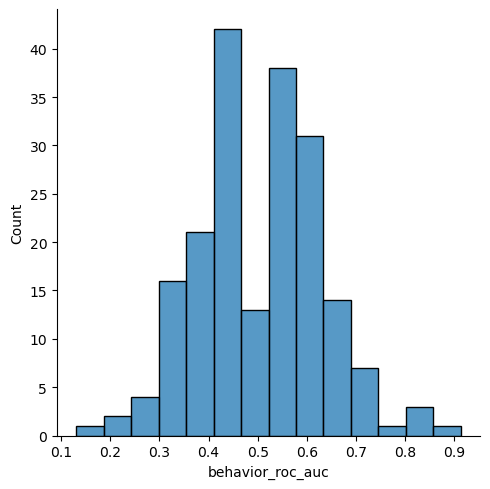

In [35]:
sns.displot(searchlight_results_df.behavior_roc_auc)

### Counterfactual baseline on B

In [36]:
plot_row = searchlight_results_df.iloc[0]
plot_side = "left" if plot_row.left_is_best else "right"

orig_rval = getattr(plot_row, f"corr_{plot_side}")
print(f"Original result: r = {getattr(plot_row, f'corr_{plot_side}')}, "
      f"p = {getattr(plot_row, f'p_val_{plot_side}')}")

print("Result through counterfactual pipeline (should match):")
_, (cfac_rval, cfac_pval) = causal4.counterfactual_baseline(
    plot_row.subject, plot_row.phoneme_pair, plot_row.population_A,
    plot_row.electrode_idx,
    getattr(plot_row, f"window_start_samp_{plot_side}"),
    getattr(plot_row, f"window_end_samp_{plot_side}"),
    searchlight_decoder_outputs, searchlight_electrode_activations,
    sanity_check=True,
    left=plot_row.left_is_best
)[0]

print(f"Counterfactual result: r = {cfac_rval}, p = {cfac_pval}")
np.testing.assert_almost_equal(orig_rval, cfac_rval,
                               err_msg="Counterfactual pipeline did not return the expected result.")

Original result: r = 0.4175122083559414, p = 2.3146493088784242e-05
Result through counterfactual pipeline (should match):
Counterfactual result: r = 0.4175122083559414, p = 2.3146493088784242e-05


In [37]:
def counterfactual_for_row(row):
    start_samp = row.window_start_samp_left if row.left_is_best else row.window_start_samp_right
    end_samp = row.window_end_samp_left if row.left_is_best else row.window_end_samp_right
    ret = causal4.counterfactual_baseline(
        row.subject, row.phoneme_pair, row.population_A,
        row.electrode_idx, start_samp, end_samp,
        searchlight_decoder_outputs, searchlight_electrode_activations,
        sanity_check=False,
        left=row.left_is_best
    )

    if len(ret) == 0:
        # No counterfactual results, return NaNs
        return pd.Series({
            "counterfactual_spearmanr": np.nan,
            "counterfactual_spearmanr_list": [],
            "counterfactual_spearmanr_z": np.nan,
            "counterfactual_test_z": np.nan,
            "counterfactual_test_p": np.nan,
            "counterfactual_n": 0,
        })

    counterfactual_df = pd.DataFrame([
        {
            "subject": subject,
            "phoneme_pair": phoneme_pair,
            "population_A": population_A,
            "spearmanr": stat.statistic,
            "p_val": stat.pvalue,
        }
        for (subject, phoneme_pair, population_A), stat in ret
    ])
    # Fisher z-transform the Spearman correlation
    counterfactual_df["spearmanr_z"] = np.arctanh(counterfactual_df.spearmanr)

    # compute statistic on the observed Spearman correlation
    spearmanr_obs = row.corr_left if row.p_val_left < row.p_val_right else row.corr_right
    z_stat = (np.arctanh(spearmanr_obs) - counterfactual_df.spearmanr_z.mean()) / counterfactual_df.spearmanr_z.std()
    dof = len(counterfactual_df) - 1  # degrees of freedom
    p_value = 2 * stats.t.sf(np.abs(z_stat), dof)

    return pd.Series({
        "counterfactual_spearmanr": counterfactual_df.spearmanr.mean(),
        "counterfactual_spearmanr_list": counterfactual_df.spearmanr.tolist(),
        "counterfactual_spearmanr_z": counterfactual_df.spearmanr_z.mean(),

        "counterfactual_test_z": z_stat,
        "counterfactual_test_p": p_value,
        "counterfactual_n": len(counterfactual_df),
    })

In [38]:
plot_row = searchlight_results_df.loc[12070]
plot_side = "left" if plot_row.left_is_best else "right"
causal4.counterfactual_baseline(
    plot_row.subject, plot_row.phoneme_pair, plot_row.population_A,
    plot_row.electrode_idx,
    getattr(plot_row, f"window_start_samp_{plot_side}"),
    getattr(plot_row, f"window_end_samp_{plot_side}"),
    searchlight_decoder_outputs, searchlight_electrode_activations,
    sanity_check=False,
    left=plot_row.left_is_best
)

[(('EC282', 'pb', '3'),
  SignificanceResult(statistic=0.06719496309161962, pvalue=0.6499855054113265)),
 (('EC282', 'pb', '3'),
  SignificanceResult(statistic=-0.1422058184976118, pvalue=0.3349596157271181)),
 (('EC282', 'pb', '3'),
  SignificanceResult(statistic=-0.20614415979157621, pvalue=0.15980981228048283)),
 (('EC282', 'pb', '3'),
  SignificanceResult(statistic=0.21710811984368214, pvalue=0.13826999137832743)),
 (('EC282', 'pb', '3'),
  SignificanceResult(statistic=-0.0261615284411637, pvalue=0.8598974207152168)),
 (('EC282', 'pb', '3'),
  SignificanceResult(statistic=-0.10052105948762484, pvalue=0.49663264401696183)),
 (('EC282', 'pb', '3'),
  SignificanceResult(statistic=-0.09769865392965696, pvalue=0.5088579343741186)),
 (('EC282', 'pb', '3'),
  SignificanceResult(statistic=0.0401650021710812, pvalue=0.7863560416142737)),
 (('EC282', 'pb', '3'),
  SignificanceResult(statistic=0.15718627876682587, pvalue=0.2859889092102401)),
 (('EC282', 'pb', '3'),
  SignificanceResult(stati

In [39]:
searchlight_results_df.query("subject == 'EC270' and phoneme_pair == 'pb' and population_A == '3' and electrode_idx == 70")

,long_name,type,roi,speech_responsive,control_corr_left,control_corr_right,control_p_val_left,control_p_val_right,corr_left,corr_right,...,window_end_samp_left,window_end_samp_right,window_start_left,window_start_right,window_start_samp_left,window_start_samp_right,left_is_best,p_val_min,control_p_val_min,behavior_roc_auc
12070,Temporal71,grid,superiortemporal,True,0.112987,0.143923,0.444502,0.329095,-0.406101,0.169561,...,270.0,270,2.0,2.0,240.0,240,True,0.004184,0.444502,0.695652


In [40]:
searchlight_results_df = pd.concat([
    searchlight_results_df,
    searchlight_results_df.progress_apply(counterfactual_for_row, axis=1)
], axis=1)

  0%|          | 0/206 [00:00<?, ?it/s]

## Plot

In [41]:
# pre-compute bounds for TIMIT plots
timit_bounds = viz.precompute_timit_bounds(timit_epoch_sources, subjects=epochs.keys())

  0%|          | 0/10 [00:00<?, ?it/s]

EC279 not found in /userdata/jgauthier/projects/ideal-word-representations/phoneme_epochs-all.h5
EC279 not found in /userdata/jgauthier/projects/ideal-word-representations/phoneme_epochs-onsets.h5


In [42]:
# cache z-score parameters for each subject and electrode
parameter_cache = {}

def plot_searchlight_response(row):
    subject = row.subject
    phoneme_pair = row.phoneme_pair
    population_A = row.population_A
    population_B = [row.electrode_idx]
    left = row.left_is_best
    population_B_window = (int(row.window_start_samp_left), int(row.window_end_samp_left)) \
        if left else (int(row.window_start_samp_right), int(row.window_end_samp_right))

    plot_key = (subject, phoneme_pair, population_A)
    plot_num_quantiles = 4
    plot_meta = all_results_meta[plot_key, 0]

    population_A_spec = populations_dict[(subject, phoneme_pair, population_A)]
    population_A_window = population_A_spec["window_a"]
    # convert to samples
    population_A_window = (
        plot_meta.epochs.time_as_index(population_A_window[0])[0],
        plot_meta.epochs.time_as_index(population_A_window[1])[0],
    )

    # sanity check: test trials are the same across repeats
    test_trial_indices = np.array([all_results_meta[(plot_key, repeat)].test_trial_metadata.index
                                    for repeat in range(n_repeats)]).T
    for i in range(1, test_trial_indices.shape[1]):
        np.testing.assert_array_equal(
            test_trial_indices[:, i],
            test_trial_indices[:, 0],
        )

    # merge estimated probabilities from repeats
    p_gt_phoneme = np.array([all_results_meta[(plot_key, repeat)].p_gt_phoneme
                            for repeat in range(n_repeats)]).T
    p_gt_phoneme_binned = pd.qcut(p_gt_phoneme.mean(1), plot_num_quantiles)

    plot_meta_df = plot_meta.test_trial_metadata.copy()
    plot_meta_df["p_gt_phoneme"] = p_gt_phoneme.mean(1)
    plot_meta_df["p_gt_phoneme_binned"] = p_gt_phoneme_binned
    plot_meta_df["p_gt_phoneme_bin_center"] = plot_meta_df.p_gt_phoneme_binned.apply(
        lambda x: x.mid
    ).astype(float).round(3)

    def get_textgrid_path(row):
        return Path(tg_dir) / (Path(row.wav_file).with_suffix(".TextGrid").name)
    plot_meta_df["textgrid_path"] = plot_meta_df.apply(get_textgrid_path, axis=1)
    plot_meta_df = plot_meta_df.rename_axis("epoch_idx").reset_index()

    # cross by electrodes
    plot_meta_df = pd.merge(plot_meta_df,
                 electrode_df.loc[plot_meta.subject].loc[population_B].reset_index(),
                 how="cross")

    ####

    g_scatter = causal4.plot_causal4_scatter(
        plot_meta, plot_meta_df, subject, population_B_window)

    ####

    # displot showing spearmanr results
    spearmanr_results = np.array(row.counterfactual_spearmanr_list)
    g_displot = sns.displot(
        spearmanr_results,
        kind="kde", fill=True, color="blue",
        height=2.5, aspect=3,
    )
    spearmanr_obs = row.corr_left if row.p_val_left < row.p_val_right else row.corr_right
    g_displot.ax.axvline(spearmanr_obs, color="red", linestyle="--", label="Observed", linewidth=2)
    g_displot.ax.set_xlabel("Spearman correlation")
    g_displot.ax.set_title(f"Permutation baseline results\n(z={row.counterfactual_test_z:.2f}, p={row.counterfactual_test_p:.2g})")

    ####

    g = causal4.plot_causal4_evoked(
        plot_meta, plot_meta_df, subject, population_A_window, population_B_window,
        hue="p_gt_phoneme_bin_center"
    )

    ####

    # plot re-aligned to behavior
    def plot_facet_evoked_align_behavior(data, color, **kwargs):
        electrode_idx = data.electrode_idx.iloc[0]
        epoch_idxs = data.epoch_idx

        word_end = data.word_end.iloc[0]
        tg_path = data.textgrid_path.iloc[0]
        tg = textgrid.TextGrid.fromFile(str(tg_path))

        ax = plt.gca()
        ax.set_xlabel("Time relative to behavior onset (sec)")
        ax.set_ylabel("HGA")
        ax.set_title(f"{subject} {electrode_idx + 1}, {word_end}")

        # plot epoched response at this electrode
        plot_epochs = plot_meta.epochs[epoch_idxs]
        plot_epochs = causal4.realign_epochs_by_behavior(plot_epochs)

        plot_epoch_data = plot_epochs.copy().pick(electrode_idx).get_data().squeeze(1)
        assert plot_epoch_data.ndim == 2  # n_trials * n_times

        plot_times = plot_epochs.times
        plot_epoch_data_mean = np.nanmean(plot_epoch_data, 0)
        plot_epoch_data_sem = np.nanstd(plot_epoch_data, 0) / np.sqrt((~np.isnan(plot_epoch_data)).sum(0))
        ax.plot(plot_times, plot_epoch_data_mean, color=color, alpha=0.5, **kwargs)
        ax.fill_between(plot_times, plot_epoch_data_mean - plot_epoch_data_sem,
                        plot_epoch_data_mean + plot_epoch_data_sem, color=color, alpha=0.2)
        
        ax.set_xlim(plot_epochs.times[0], plot_epochs.times[-1])

        return ax
    
    g_evoked_by_behavior = sns.FacetGrid(
        plot_meta_df,
        row="electrode_idx",
        hue="p_gt_phoneme_bin_center", palette="plasma",
        col="lexical_evidence",
        aspect=3, height=3, sharey="row"
    ).map_dataframe(plot_facet_evoked_align_behavior).add_legend()
    g_evoked_by_behavior.fig.suptitle("Evoked responses by P(gt phoneme), aligned to behavior onset")

    ####

    g_evoked_resampled = causal4.plot_causal4_evoked(
        plot_meta, plot_meta_df, subject, population_A_window, population_B_window,
        hue="resampled"
    )

    ####

    g_raster = causal4.plot_causal4_raster(
        plot_meta, plot_meta_df, subject, population_B_window,
        sort_by="p_gt_phoneme", parameter_cache=parameter_cache)
    
    g_raster_resampled = causal4.plot_causal4_raster(
        plot_meta, plot_meta_df, subject, population_B_window,
        sort_by="resampled", parameter_cache=parameter_cache)
    
    g_raster_behavior = causal4.plot_causal4_raster(
        plot_meta, plot_meta_df, subject, population_B_window,
        sort_by="behavior_linear", parameter_cache=parameter_cache)

    ####

    timit_fig = viz.timit_subplots(
        subject, population_B[0],
        plot_phonemes=[ph.upper() for ph in phoneme_pair],
        cell_aspect=1.5,
        epoch_sources=timit_epoch_sources,
        timit_bounds_dict=timit_bounds)
    timit_fig.suptitle(f"TIMIT responses for {subject} {population_B[0] + 1}")

    return (g_scatter, g_displot,
            g, g_evoked_by_behavior, g_evoked_resampled,
            g_raster, g_raster_resampled, g_raster_behavior,
            timit_fig)

long_name                                                           AnteriorGrid99
type                                                                          grid
roi                                                               superiortemporal
speech_responsive                                                             True
control_corr_left                                                        -0.134822
control_corr_right                                                        0.039337
control_p_val_left                                                        0.190309
control_p_val_right                                                       0.703558
corr_left                                                                  0.37439
corr_right                                                               -0.276953
electrode_idx                                                                   98
electrode_in_A                                                               False
p_va

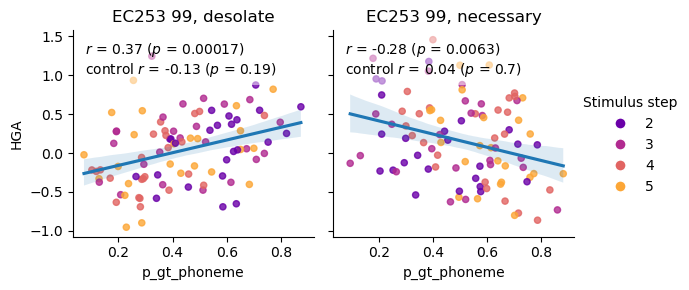

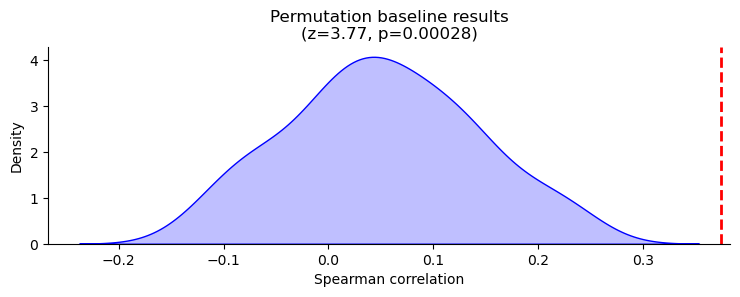

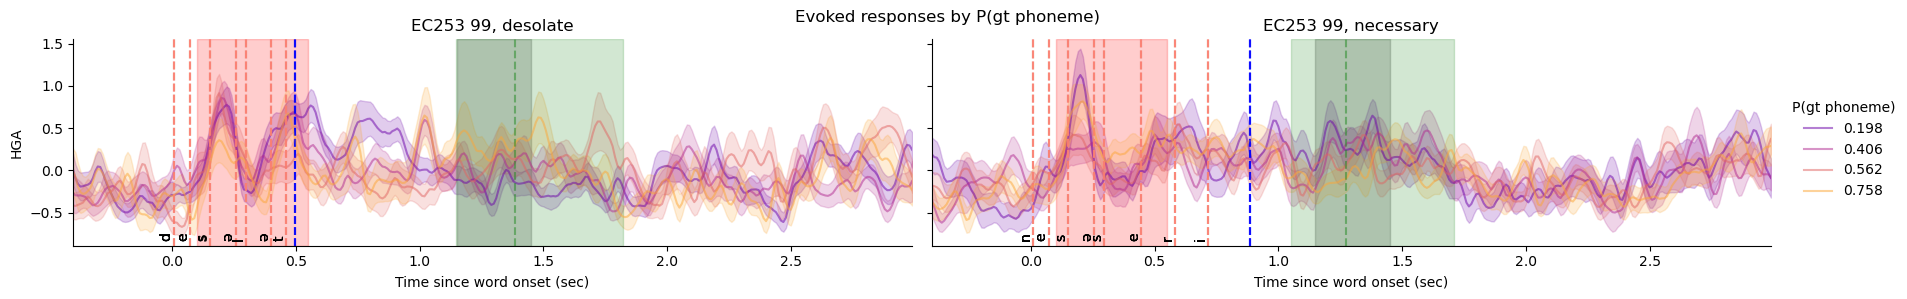

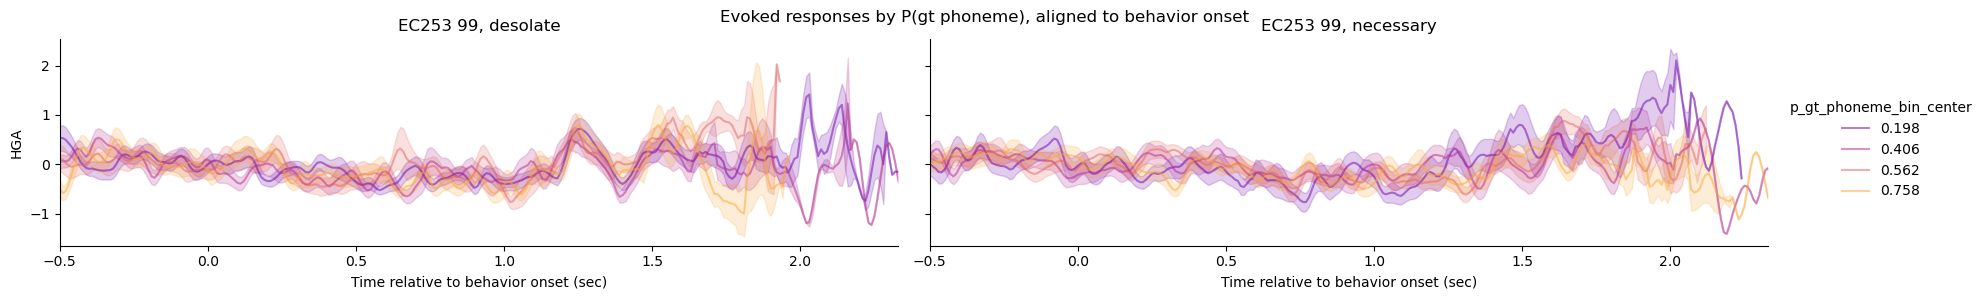

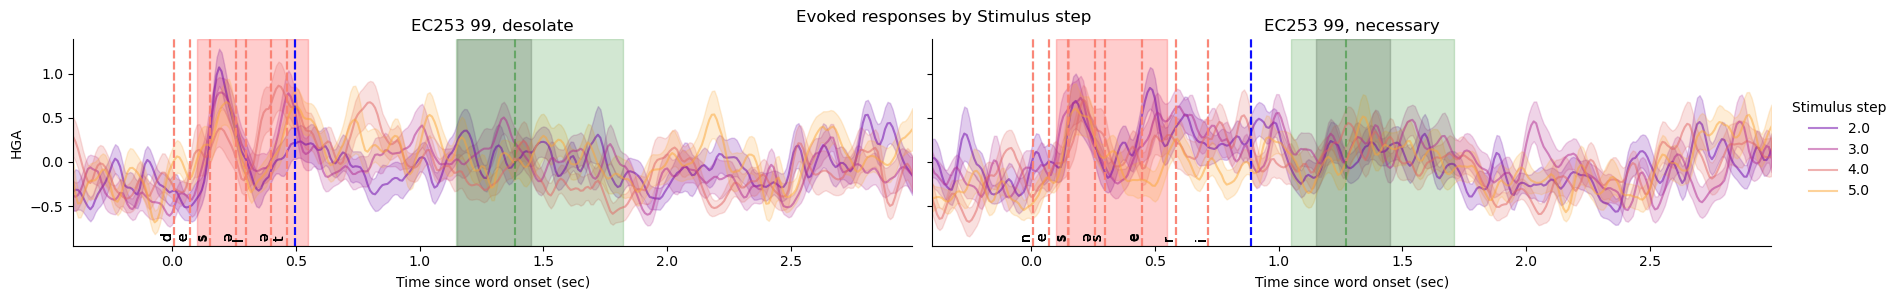

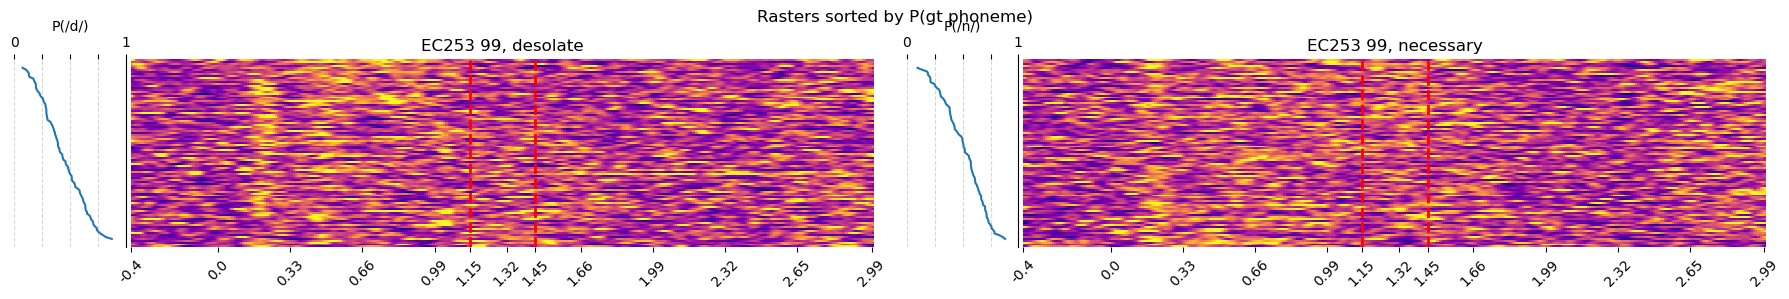

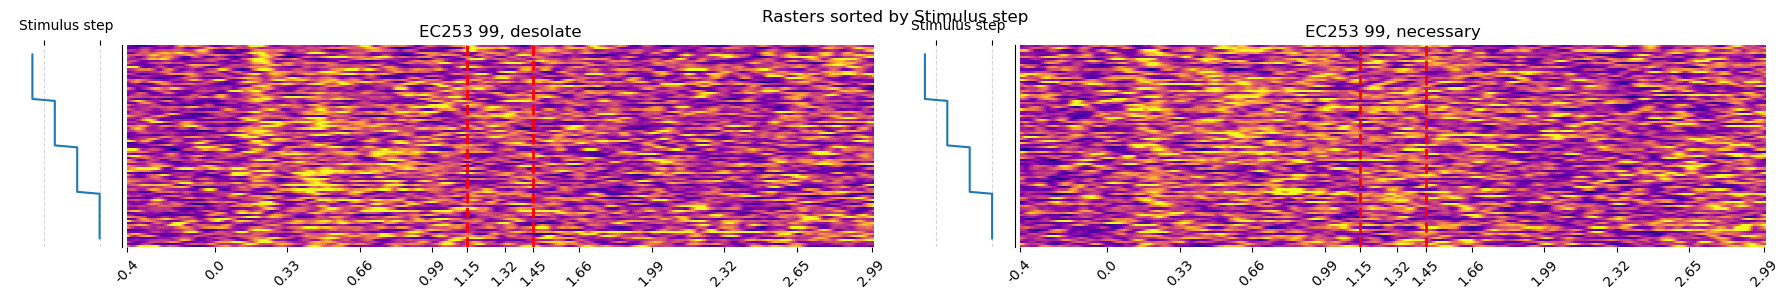

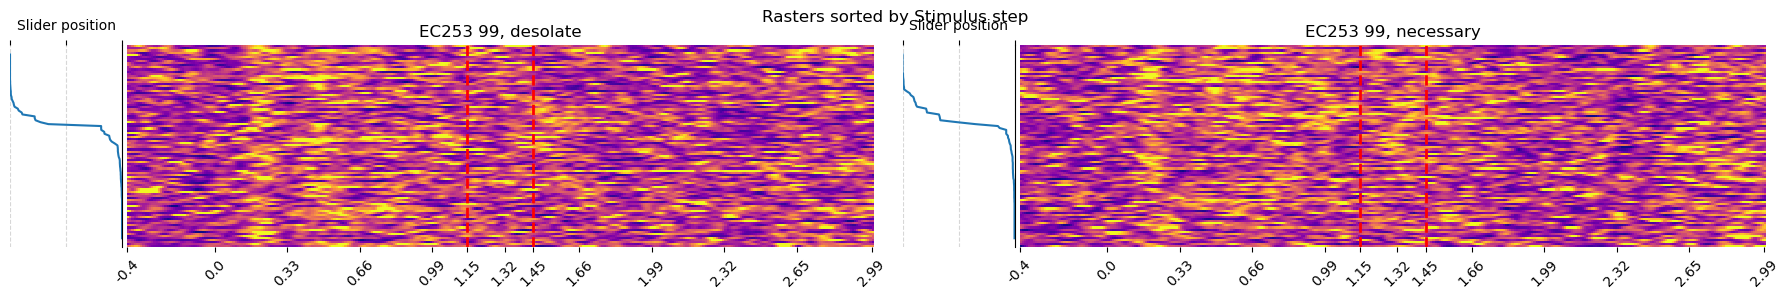

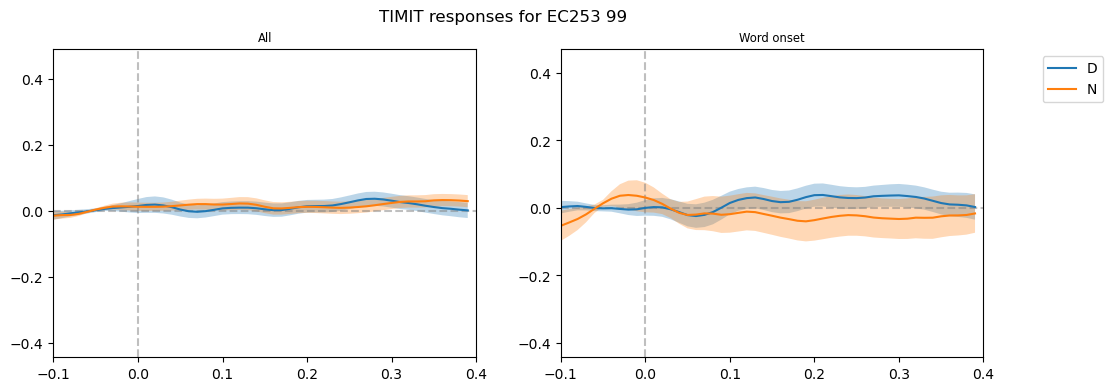

In [54]:
plot_row =  searchlight_results_df.iloc[3]
print(plot_row)
plot_searchlight_response(plot_row)
None

In [85]:
decoder_results.to_csv(f"{outdir}/decoder_results.csv")

In [86]:
searchlight_results_df.to_csv(f"{outdir}/searchlight_results.csv")

In [83]:
torch.save({"all_results_meta": all_results_meta,
            "searchlight_results_df": searchlight_results_df,
            "searchlight_electrode_activations": searchlight_electrode_activations,
            "searchlight_decoder_outputs": searchlight_decoder_outputs,
            "populations_dict": populations_dict,
            }, f"{outdir}/searchlight_results.pth")

In [84]:
ls -lh {outdir}

total 3.2G
-rw-r--r-- 1 jgauthier c_lab 4.9K Jul  3 16:41 causal_candidate_populations.json
-rw-r--r-- 1 jgauthier c_lab  11K Jul  3 16:41 decoder_results.csv
-rw-r--r-- 1 jgauthier c_lab 4.4G Jul  3 16:43 searchlight_results.pth


In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages(f"{outdir}/searchlight_results.pdf") as pdf:
    for _, row in tqdm(searchlight_results_df.sort_values("p_val_min").iterrows(), total=len(searchlight_results_df)):
        facetgrids = plot_searchlight_response(row)
        for fg in facetgrids:
            fg.tight_layout()
            fig = fg.fig if hasattr(fg, 'fig') else fg
            pdf.savefig(fig)
            plt.close(fig)

  0%|          | 0/198 [00:00<?, ?it/s]

<string>:25: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
<string>:25: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
<string>:25: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
<string>:25: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.


In [ ]:
# Load results with manual annotations
searchlight_manual = pd.read_csv("causal4_searchlight_results_manual.csv", index_col=0)

In [ ]:
realign_epochs_by_behavior(epochs["EC282"])

Adding metadata with 100 columns
421 matching events found
No baseline correction applied
0 projection items activated


<EpochsArray | 421 events (all good), -0.5 – 2.45 s (baseline off), ~213.1 MiB, data loaded, with metadata,
 '1': 421>

In [ ]:
if not (searchlight_manual.index == searchlight_results_df.index).all():
    raise ValueError("Manual annotations do not match the current searchlight results. "
                     "Probably need to repeat manual annotations.")

In [ ]:
all_results_meta.keys()

dict_keys([(('EC282', 'dn', '5'), 0), (('EC253', 'dn', '0'), 0), (('EC282', 'dn', '0'), 0), (('EC270', 'dn', '5'), 0), (('EC253', 'dn', '5'), 0), (('EC287', 'dn', '5'), 0), (('EC282', 'bm', '3'), 0), (('EC270', 'dn', '0'), 0), (('EC250', 'dn', '5'), 0), (('EC260', 'dn', '5'), 0), (('EC282', 'bm', '6'), 0), (('EC243', 'bm', '6'), 0), (('EC270', 'pb', '3'), 0), (('EC282', 'pb', '3'), 0), (('EC250', 'bm', '6'), 0), (('EC282', 'dn', '5'), 1), (('EC253', 'dn', '0'), 1), (('EC282', 'dn', '0'), 1), (('EC270', 'dn', '5'), 1), (('EC253', 'dn', '5'), 1), (('EC287', 'dn', '5'), 1), (('EC282', 'bm', '3'), 1), (('EC270', 'dn', '0'), 1), (('EC250', 'dn', '5'), 1), (('EC260', 'dn', '5'), 1), (('EC282', 'bm', '6'), 1), (('EC243', 'bm', '6'), 1), (('EC270', 'pb', '3'), 1), (('EC282', 'pb', '3'), 1), (('EC250', 'bm', '6'), 1), (('EC282', 'dn', '5'), 2), (('EC253', 'dn', '0'), 2), (('EC282', 'dn', '0'), 2), (('EC270', 'dn', '5'), 2), (('EC253', 'dn', '5'), 2), (('EC287', 'dn', '5'), 2), (('EC282', 'bm', 

Not setting metadata
192 matching events found
No baseline correction applied
0 projection items activated


/tmp/ipykernel_2934426/3250237573.py:14: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  plot_ep.plot_image(


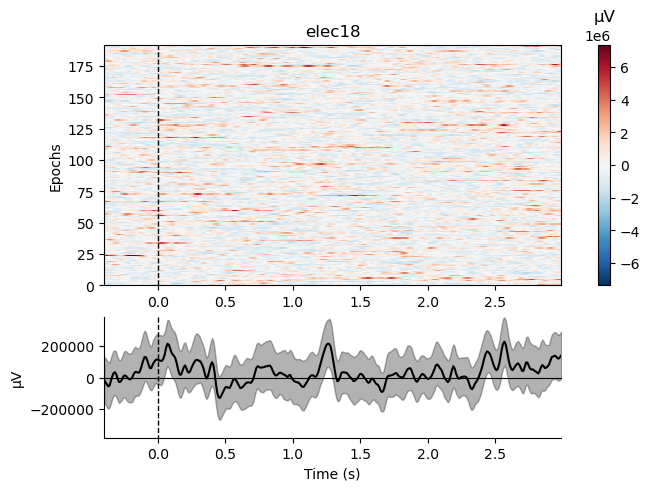

[<Figure size 640x480 with 3 Axes>]

In [ ]:
plot_subject = "EC260"
plot_electrode_idx = 18
plot_phoneme_pair = "dn"
plot_population_A = "5"
plot_key = (plot_subject, plot_phoneme_pair, plot_population_A)

plot_results = all_results_meta[plot_key, 0]
plot_ep = plot_results.epochs[plot_results.test_trial_metadata.index]
p_gt_phoneme = np.array([all_results_meta[(plot_key, repeat)].p_gt_phoneme
                            for repeat in range(n_repeats)]).T
p_gt_phoneme = p_gt_phoneme.mean(1)

rts = plot_ep.metadata["slider.rt"].combine(plot_ep.tmax, min)
plot_ep.plot_image(
    picks=[plot_electrode_idx],
    # overlay_times=rts,
    order=p_gt_phoneme.argsort())

In [ ]:
prev_results.epochs.plot_image(picks=[])

In [ ]:
searchlight_manual

## Cross-reference with EOIs

In [68]:
searchlight_results_df.head()[["subject", "electrode_idx"]]

,subject,electrode_idx
2500,EC250,196
5173,EC253,53
2852,EC250,36
5218,EC253,98
2684,EC250,124


In [69]:
eoi_df = pd.read_csv("outputs/trf_eois/eois.csv")

In [70]:
eoi_df

,subject,feature_block,electrode,unique_variance
0,EC250,acoustic,215,0.017799
1,EC282,acoustic,84,0.011961
2,EC248,acoustic,382,0.011833
3,EC243,mismatch,102,0.011563
4,EC260,mismatch,204,0.011078
...,...,...,...,...
524,EC278,mismatch,41,-0.004567
525,EC253,mismatch,3,-0.004804
526,EC253,mismatch,122,-0.005145
527,EC253,mismatch,23,-0.005581


In [71]:
eoi_df_wide = eoi_df.rename(columns={"electrode": "electrode_idx"}).pivot_table(index=["subject", "electrode_idx"], columns="feature_block", values="unique_variance")
eoi_df_wide

feature_block          acoustic  lexical_evidence  mismatch
subject electrode_idx                                      
EC243   59            -0.000017         -0.000487 -0.001147
        71             0.001822         -0.000356 -0.002087
        72            -0.000048         -0.000607  0.000116
        87             0.002814         -0.001063 -0.000427
        88             0.001250         -0.000704 -0.002367
...                         ...               ...       ...
EC287   76                  NaN         -0.001539 -0.000273
        124            0.000033          0.000114  0.000891
        146           -0.001936               NaN -0.001755
        147           -0.000032          0.002225 -0.001596
        182            0.000048         -0.000447 -0.000579

[194 rows x 3 columns]

In [72]:
mrg = pd.merge(searchlight_results_df, eoi_df_wide, left_on=["subject", "electrode_idx"], right_index=True, how="left")
mrg

,long_name,type,roi,speech_responsive,control_corr_left,control_corr_right,control_p_val_left,control_p_val_right,corr_left,corr_right,...,behavior_roc_auc,counterfactual_spearmanr,counterfactual_spearmanr_list,counterfactual_spearmanr_z,counterfactual_test_z,counterfactual_test_p,counterfactual_n,acoustic,lexical_evidence,mismatch
2500,Inferior69,grid,superiortemporal,True,-0.089097,-0.047070,0.388000,0.648820,0.417512,0.016522,...,0.498584,-0.002007,"[0.060987950525634514, 0.02891725410685947, 0....",-0.002057,6.175334,8.914537e-08,55,NaN,NaN,NaN
5173,AnteriorGrid54,grid,precentral,True,-0.022190,0.109606,0.830082,0.287757,0.397436,-0.092065,...,0.554566,0.001418,"[0.14921343777729262, 0.0020423812908501146, -...",0.001518,4.343640,3.393333e-05,100,-0.000377,0.000123,-0.000358
2852,Superior37,grid,precentral,True,-0.099183,-0.125408,0.336332,0.223429,0.127116,0.381918,...,0.677544,-0.017325,"[0.11277807921866521, -0.05417797069994574, -0...",-0.017525,4.131137,1.448050e-02,5,NaN,NaN,NaN
5218,AnteriorGrid99,grid,superiortemporal,True,-0.134822,0.039337,0.190309,0.703558,0.374390,-0.276953,...,0.347768,0.051405,"[0.029156959421013758, 0.02055145996596518, 0....",0.051892,3.768441,2.792788e-04,100,NaN,NaN,NaN
2684,Superior125,grid,precentral,True,-0.042363,-0.053122,0.681939,0.607230,0.373114,-0.083736,...,0.384718,-0.026459,"[-0.072203569363726, 0.05231996651955152, 0.14...",-0.026667,4.677859,1.982196e-05,55,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11422,Temporal95,grid,supramarginal,True,0.087430,0.010761,0.554588,0.942133,-0.137538,-0.369518,...,0.326087,-0.084108,"[-0.017042987407729047, -0.16728180633955708, ...",-0.084669,-4.294315,1.270265e-02,5,NaN,NaN,NaN
5030,PosteriorGrid39,grid,supramarginal,True,-0.047406,0.186263,0.646480,0.069213,0.076601,0.262032,...,0.548695,0.022098,"[0.09425161242483808, 0.22237152290085788, 0.1...",0.022318,1.918391,5.794246e-02,100,NaN,NaN,NaN
9643,Temporal108,grid,supramarginal,True,0.040352,-0.018831,0.785383,0.898911,0.240230,-0.368650,...,0.568700,0.005567,"[-0.10660008684324793, 0.08912288319583152, 0....",0.005706,-3.029699,2.764592e-03,205,-0.001712,NaN,-0.000036
4050,Inferior83,grid,precentral,True,-0.033621,0.129106,0.745031,0.209964,-0.057501,0.261951,...,0.564091,0.034036,"[-0.02573776669592392, 0.1269225320047894, -0....",0.034426,2.444202,1.561013e-02,160,NaN,NaN,NaN


In [78]:
mrg.loc[mrg.p_val_min == mrg.p_val_left, "corr_best"] = mrg.loc[mrg.p_val_min == mrg.p_val_left, "corr_left"].abs()
mrg.loc[mrg.p_val_min == mrg.p_val_right, "corr_best"] = mrg.loc[mrg.p_val_min == mrg.p_val_right, "corr_right"].abs()
mrg["log_p_val_min"] = np.log10(mrg.p_val_min)

<Axes: xlabel='log_p_val_min', ylabel='mismatch'>

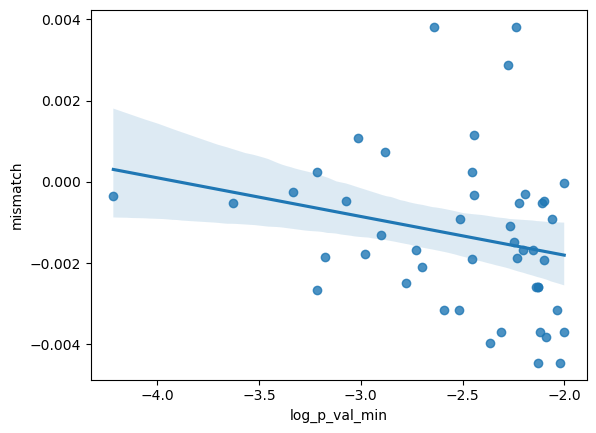

In [80]:
sns.regplot(data=mrg.reset_index(), x="log_p_val_min", y="mismatch")

## Cross-reference with single electrode decoding

In [64]:
dec_df = pd.read_csv("outputs/single_electrode_decoding/10/acoustic/scores.csv")

In [65]:
dec_summary = dec_df.groupby(["subject", "electrode_idx", "phoneme_pair"]).roc_auc.max()

In [66]:
mrg = pd.merge(searchlight_results_df,
         dec_summary.rename("lexical_evidence_roc_auc"),
         left_on=["subject", "electrode_idx", "phoneme_pair"],
         right_index=True, how="left")

mrg["log_p_val_min"] = -np.log10(mrg.p_val_min)

<Axes: xlabel='log_p_val_min', ylabel='lexical_evidence_roc_auc'>

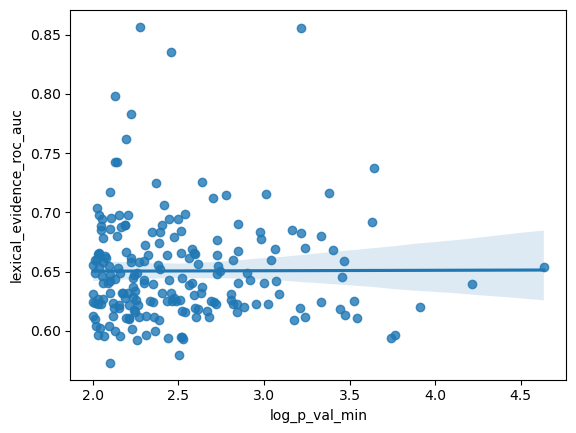

In [67]:
sns.regplot(data=mrg.reset_index(), x="log_p_val_min", y="lexical_evidence_roc_auc",)